In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import os
import time as tm
import sys
sys.path.append('..')
import Sprayer_PDE as SP

import pypolo2

# Environment -- PINNS

In [2]:
# 初始化参数和环境污染浓度
Setting = pypolo2.utilities.Config()

In [3]:
# 确定存放地址
starttime = Setting.starttime.replace(' ', '-').replace(':', '-')
Savedir = '{}/{}/teamsize_{}'.format(Setting.root_dir,Setting.strategy_name,Setting.team_size)
Savename = 'seed{}'.format(Setting.seed)
Setting.save_dir = Savedir
Setting.save_name = Savename
evaluator = pypolo2.experiments.Evaluator()
logger = pypolo2.experiments.Logger(None, Setting)

# Sensor

In [4]:
sensor = pypolo2.sensors.Sprinkler(
    Setting = Setting
)

# Pilot Survey

In [5]:
rng = pypolo2.experiments.utilities.seed_everything(Setting = Setting)

Set random seed to 7 in random, numpy, and torch.


# Set initual data

In [6]:
# 初始化污染源
if Setting.randomsource == True:
    # gengerate two set of random numbers for source locations
    numbers = rng.randint(0, 19, size=Setting.sourcenum * 2)
    pairs = rng.choice(numbers, size=(Setting.sourcenum, 2), replace=False)
    for i in range(Setting.sourcenum):
        number = rng.randint(50, 70, size=1)
        Setting.RR[i,0] = int(pairs[i,0])
        Setting.RR[i,1] = int(pairs[i,1])
        Setting.RR[i,2] = number

# 初始化污染分布
Setting.R =  -3 * np.ones((Setting.grid_x, Setting.grid_y)) + 6 * np.random.random((Setting.grid_x, Setting.grid_y))
for i in range(Setting.sourcenum):
        Setting.R[Setting.RR[i,0],Setting.RR[i,1]] = Setting.RR[i,2]

env_model = SP.Diffusion_Model(x_range = Setting.grid_x, y_range = Setting.grid_y,\
                 initial_field =  Setting.env, R_field =  Setting.R, data_sprayer_train = Setting.data_sprayer_train, t_start = 0) # build model
Setting.env = env_model.solve(10)[-1]
sensor.set_env(Setting.env)

# 初始化高斯过程回归需要的参数
env_model = SP.Diffusion_Model(x_range = Setting.grid_x, y_range = Setting.grid_y,\
                 initial_field =  Setting.env, R_field =  Setting.R, data_sprayer_train = Setting.data_sprayer_train, t_start = 0) # build model

y_init = np.zeros((Setting.num_init_samples,1))
y_stations = np.zeros((Setting.station_size*Setting.time_before_sche,1))
time_init = np.zeros((Setting.num_init_samples,1))
time_stations = np.zeros((Setting.station_size*Setting.time_before_sche,1))

for time in range(Setting.time_before_sche):
    time_stations[Setting.station_size*time:Setting.station_size*(time+1)] = (time-Setting.time_before_sche+1)*1
    Setting.env = env_model.solve((time+1)*5)[-1] # 推进5分钟
    sensor.set_env(Setting.env)
    
#假设每次观测后均变化时间，环境也随之发生变化
for time in range(Setting.num_init_samples):
    y_init[time] = sensor.sense(states=Setting.x_init[time], rng=rng).reshape(-1, 1)
    if time == 0:
        y_stations[:] = y_init[time] - 20
    time_init[time] = (time+1)*1
    Setting.env = env_model.solve((1+Setting.time_before_sche+time)*5)[-1]
    sensor.set_env(Setting.env)
    
Setting.x_init = np.hstack((Setting.x_init,time_init))

Setting.x_stations = Setting.x_station
for i in range(Setting.time_before_sche-1):
    Setting.x_stations = np.vstack((Setting.x_stations,Setting.x_station))
Setting.x_stations = np.hstack((Setting.x_stations,time_stations))

Setting.x_init = np.vstack((Setting.x_stations,Setting.x_init))
y_init = np.vstack((y_stations,y_init))

100%|██████████| 1.0/1.0 [00:00<00:00,  2.31it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00, 10.78it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00, 10.23it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00, 10.46it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00, 10.44it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00, 10.23it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00, 10.03it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00, 10.28it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00, 10.67it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00, 10.44it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.29it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00, 10.23it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  9.73it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  9.93it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00, 10.28it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00, 10.44it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  9.64it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00, 10.45it/s]    
100%|██████████| 1.0/1.0 [00

# Model

In [7]:
Setting.time_stamp = Setting.x_init[:,2].max(axis=0, keepdims=False)
kernel = pypolo2.kernels.RBF(Setting)
model = pypolo2.models.GPR(
    x_train=Setting.x_init,
    y_train=y_init,
    kernel=kernel,
    noise=Setting.init_noise,
    lr_hyper=Setting.lr_hyper,
    lr_nn=Setting.lr_nn,
    is_normalized = True,
    time_stamp = Setting.time_stamp,
)

In [8]:
model.optimize(num_iter=model.num_train, verbose=True)

Iter: 05 loss:  8.64: 100%|██████████| 6/6 [00:00<00:00, 133.69it/s]


# Robot

In [9]:
vehicle_team = dict()
for i in range(Setting.team_size):
    robot = pypolo2.robots.SPRINKLER_REPLENISHANYWHERE(
        init_state = np.array([Setting.x_init[-1, 0], Setting.x_init[-1, 1]]),
        Setting = Setting
    )
    vehicle_team[i+1] = robot #因此team的id从1开始

# Strategy

In [10]:
strategy = pypolo2.strategies.MCTSSpray(
            task_extent=Setting.task_extent,
            rng=rng,
            vehicle_team=vehicle_team,
        )
Setting.strategy = strategy

# Experiment

In [11]:
#定义需要随时间更新的训练过程
def run(rng, model, Setting, sensor, evaluator, logger, vehicle_team) -> None:
    current_step = 0 #总规划长度
    adaptive_step = Setting.adaptive_step #自适应长度
    change_step = 0
    spray_effect = 0 # 洒水效果
    result, MI_information, belief_state, computed_effect = None, None, None, None
    while current_step < Setting.max_num_samples:
        # 计算用于洒水效果,环境真实值已知
        allpoint_list = []
        for i in range (Setting.task_extent[0],Setting.task_extent[1]):
            for j in range (Setting.task_extent[2],Setting.task_extent[3]):
                allpoint_list.append([i, j, model.time_stamp])
        allpoint = np.array(allpoint_list)

        mean, _ = model(allpoint)
        sprayeffect_all = pypolo2.objectives.sprayeffect.spray_effect(allpoint, allpoint, mean, Setting.task_extent).ravel()
        # 计算信息量，这里计算的是所有已观测的信息对当前时刻每个点的污染分布的信息量
        prior_diag_std, poste_diag_std, _, _ = model.prior_poste(allpoint)
        hprior = pypolo2.objectives.entropy.gaussian_entropy(prior_diag_std.ravel())
        hposterior = pypolo2.objectives.entropy.gaussian_entropy(poste_diag_std.ravel())
        mi_all = hprior - hposterior
        if np.any(mi_all < 0.0):
            print(mi_all.ravel())
            raise ValueError("Predictive MI < 0.0!")

        # 将不确定情况、belief_state、预计洒水效果进行重排。
        MI_information = np.zeros((Setting.task_extent[1]-Setting.task_extent[0],Setting.task_extent[3]-Setting.task_extent[2]))
        belief_state = np.zeros((Setting.task_extent[1]-Setting.task_extent[0],Setting.task_extent[3]-Setting.task_extent[2]))
        computed_effect = np.zeros((Setting.task_extent[1]-Setting.task_extent[0],Setting.task_extent[3]-Setting.task_extent[2]))
        for i in range (Setting.task_extent[0],Setting.task_extent[1]):
            for j in range (Setting.task_extent[2],Setting.task_extent[3]):
                MI_information[i,j] = mi_all[i*(Setting.task_extent[3]-Setting.task_extent[2])+j]
                belief_state[i,j] = mean[i*(Setting.task_extent[3]-Setting.task_extent[2])+j,0]
                computed_effect[i,j] = sprayeffect_all[i*(Setting.task_extent[3]-Setting.task_extent[2])+j]
                
        Setting.current_step = current_step
        
        
        # scheduling and update agent goals ###################################################
        if adaptive_step >= Setting.adaptive_step:
            start = tm.time()
            result = Setting.strategy.get(model = model, Setting = Setting, pred = belief_state, agent_scores = [])
            adaptive_step = 0
            for id, vehicle in vehicle_team.items():
                vehicle.set_goals(result[id][0],result[id][1])
            end = tm.time()
            agent_scores = []
            print('current_step')
            print(current_step)
            print('search_time')
            print(end-start)     
            
        # calculate metrix and save 
        coverage, mean_airpollution, max_airpollution = evaluator.eval_results(Setting.env, Setting.task_extent, vehicle_team)
        logger.append(current_step, Setting.env, belief_state, MI_information, computed_effect, vehicle_team, coverage, mean_airpollution, max_airpollution, spray_effect)
           
        # change source,每经过R_change_interval后，改变源分布和强度，
        if change_step >= Setting.R_change_interval:
            Setting.R =  -3 * np.ones((Setting.grid_x, Setting.grid_y)) + 6 * np.random.random((Setting.grid_x, Setting.grid_y))
            change_step = 0
            if Setting.randomsource == True:
                # gengerate two set of random numbers for source locations
                # 20250220 rng.randint(0, 4产生的随机数在0,1,2,3范围内
                numbers = rng.randint(0, 3, size=Setting.sourcenum * 2)
                pairs = rng.choice(numbers, size=(Setting.sourcenum, 2), replace=False)
                for i in range(Setting.sourcenum):
                    number = rng.randint(50, 70, size=1)
                    if Setting.RR[i,0]+pairs[i,0]-1 < Setting.grid_x-1 and Setting.RR[i,0] + pairs[i,0] - 1 >=0:
                        Setting.RR[i,0] = int(Setting.RR[i,0]+pairs[i,0]-1)
                    if Setting.RR[i,1]+pairs[i,1]-1 < Setting.grid_y-1 and Setting.RR[i,1] + pairs[i,1] - 1 >=0:
                        Setting.RR[i,1] = int(Setting.RR[i,1]+pairs[i,1]-1)
                    Setting.RR[i,2] = number

        for i in range(Setting.sourcenum):
             Setting.R[Setting.RR[i,0],Setting.RR[i,1]] = Setting.RR[i,2]
        
        # 执行规划结果并推进仿真环境
        # 计算无洒水时的环境分布，推进表步长为1分钟
        env_model1 = SP.Diffusion_Model(x_range = Setting.grid_x, y_range = Setting.grid_y,\
                initial_field = Setting.env, R_field =  Setting.R, data_sprayer_train = Setting.data_sprayer_train, t_start = current_step * Setting.delta_t)
        env_withoutspray = env_model1.solve(Setting.delta_t)[-1]
            
        # update state 并将车辆的轨迹和洒水轨迹取出来
        x_new = []
        y_new = []
        for id, vehicle in vehicle_team.items():
            vehicle.update()
            current_state = vehicle.state.copy().reshape(1, -1)
            x_new.append(current_state)
            y_new.append(sensor.sense(current_state, rng).reshape(-1, 1))
            if Setting.current_step == 0:
                Setting.data_sprayer_train.append(pd.DataFrame())
            if vehicle.spray_flag == True:
                new_pd = pd.DataFrame({"time":(Setting.current_step + 1) * Setting.delta_t, "x":current_state[0,0],\
                                        "y":current_state[0,1], "spray_volume":200},index=[0])
                Setting.data_sprayer_train[id-1] = pd.concat([Setting.data_sprayer_train[id-1],new_pd])
            else:
                new_pd = pd.DataFrame({"time":(Setting.current_step + 1) * Setting.delta_t, "x":current_state[0,0],\
                                        "y":current_state[0,1], "spray_volume":0},index=[0])
                Setting.data_sprayer_train[id-1] = pd.concat([Setting.data_sprayer_train[id-1],new_pd])    
        # 计算带入洒水后的环境情况
        env_model2 = SP.Diffusion_Model(x_range = Setting.grid_x, y_range = Setting.grid_y,\
                initial_field =  Setting.env, R_field =  Setting.R, data_sprayer_train = Setting.data_sprayer_train, t_start = current_step * Setting.delta_t) # build model
        env_withspray = env_model2.solve(Setting.delta_t)[-1]
        
        # 疑似污染源标记
        for id, vehicle in vehicle_team.items():
            current_state = vehicle.state.copy().reshape(1, -1).astype(int)
            # 如果当前状态在污染源四周，则认为已经发现了
            for i in range(Setting.sourcenum):
                # 判断是否在周围
                if ((current_state[0,0]-Setting.RR[i,0])**2 + (current_state[0,1]-Setting.RR[i,1])**2) <= 2:
                    # 判断是否已经发现
                    in_flag = False
                    for j in range(len(Setting.sources)):
                        if Setting.RR[i,0] == Setting.sources[j][0] and Setting.RR[i,1] == Setting.sources[j][1]:
                            in_flag = True
                    if in_flag:
                        continue
                    else:
                        Setting.sources.append([Setting.RR[i,0], Setting.RR[i,1]])         
                        
        print(Setting.sources)   
        Setting.env = env_withspray
        sensor.set_env(Setting.env)
        # 移除污染标记，当beliefstate中对应的区域污染已经降低很多
        for i in range(len(Setting.sources)-1, -1, -1):
            if belief_state[Setting.sources[i][0],Setting.sources[i][1]] <= 40:
                del Setting.sources[i]    
        
        # 计算洒水效果
        spray_effect = np.sum(env_withoutspray - Setting.env)
        print(spray_effect)
            
        # using new data to update gpr model
        x_new = np.concatenate(x_new, axis=0)
        y_new = np.concatenate(y_new, axis=0)
        #add time dim
        model.time_stamp = model.time_stamp + Setting.time_co
        Setting.time_stamp = model.time_stamp
        model_input = np.zeros((x_new.shape[0],3))
        model_input[:,0:2] = x_new
        model_input[:,2:3] = model.time_stamp
        #optimize model
        model.add_data(model_input, y_new)
        model.optimize(num_iter=len(y_new), verbose=False)
        
        adaptive_step = adaptive_step + 1     
        current_step = current_step + 1
        change_step = change_step + 1  
    return 0

In [12]:
start = tm.time()
Setting.strategy = strategy
run(rng, model, Setting, sensor, evaluator, logger, vehicle_team)
# pypolo2.experiments.utilities.print_metrics(logger, Setting.max_num_samples-1)
end = tm.time()
# logger.save(end-start)  # I temporarily removed "makefile()".

[[10. 10.]
 [10. 10.]
 [10. 10.]
 [10. 10.]]
4
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] -2.096043052787886
current_step
0
search_time
3.020277261734009


100%|██████████| 1.0/1.0 [00:00<00:00,  4.62it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00, 10.15it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00, 10.49it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00, 10.59it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00, 10.39it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00, 10.37it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00, 10.58it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00, 10.87it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00, 10.44it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00, 10.08it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.44it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  9.09it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  9.94it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00, 10.31it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00, 10.29it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  9.82it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00, 10.29it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  9.35it/s]    
100%|██████████| 1.0/1.0 [00

[]
0.0


100%|██████████| 1.0/1.0 [00:00<00:00,  3.38it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  8.71it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  9.67it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  8.99it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  9.70it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  9.31it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  8.92it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  9.64it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  9.63it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  9.52it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  2.51it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.04it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.15it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  2.92it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  3.73it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  3.42it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  3.54it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.41it/s]    
100%|██████████| 1.0/1.0 [00

[]
215.35408186428822


...

[]
-0.6943311248697184


100%|██████████| 1.0/1.0 [00:00<00:00,  2.61it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.88it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  5.04it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.80it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.93it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.81it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.83it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.79it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  5.16it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.33it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  2.96it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.43it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.97it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.74it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.69it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.40it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.68it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.58it/s]    
100%|██████████| 1.0/1.0 [00

[]
-0.6737698077050205


100%|██████████| 1.0/1.0 [00:00<00:00,  2.49it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.39it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.99it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.85it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  5.16it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.32it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.28it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.91it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.63it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  5.00it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  2.90it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  5.12it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.55it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.68it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.64it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.80it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.61it/s]    
100%|██████████| 1.0/1.0 [00:00<00:00,  4.49it/s]    
100%|██████████| 1.0/1.0 [00

[]
1.9614521270219365


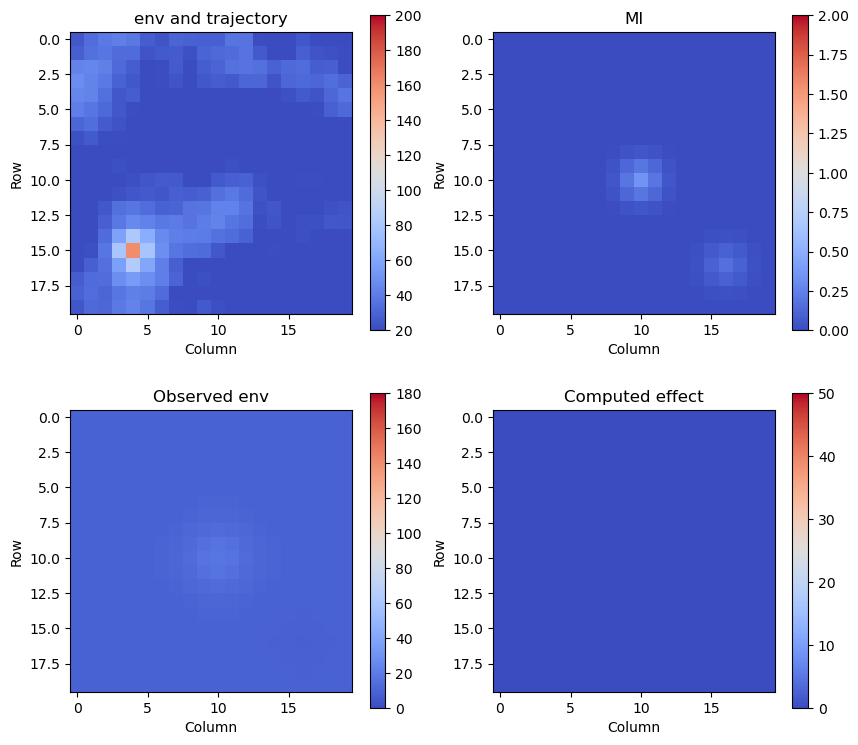

In [13]:
from pypolo2.experiments import visualizer
ani = visualizer.visual(logger)

# Display the animation
from IPython.display import HTML
HTML(ani.to_jshtml())